In [1]:
import sys
sys.path.append('../')

import pandas as pd
import matplotlib.pyplot as plt
import tqdm
import pickle
from itertools import product
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from src.mypackage.data_preparation import prepare_statistical_data
from src.mypackage.forecasting import sarimax_forecast
from src.mypackage.evaluation import print_metrics
from src.mypackage.visualization import plot_forecast
from src.mypackage.utils import set_seed, SEED
import warnings
warnings.filterwarnings("ignore")
set_seed(SEED)

In [2]:
df = pd.read_csv("../data/raw/PJME_hourly.csv")
train, test = prepare_statistical_data(df)
timesteps = test["Datetime"].copy()

In [ ]:
ps = [1, 2]
ds = [1]
qs = [0, 1]
Ps = [0, 1]
Ds = [1]
Qs = [0, 1]
ss = [24]

orders = list(product(ps, ds, qs))
seasonal_orders = list(product(Ps, Ds, Qs, ss))
params = list(product(orders, seasonal_orders))

In [ ]:
results = []
for param in tqdm.tqdm(params):
    o, so = param
    model = SARIMAX(train["PJME_MW"][-365*24*1:], order=o, seasonal_order=so)   # 計算時間削減のため、訓練データの時間ステップは1年分とする
    result = model.fit(disp=False)
    results.append((param, result.bic))

100%|██████████| 16/16 [09:42<00:00, 36.41s/it]


In [5]:
# 最もBICが小さいモデルを選択
best_param, best_result = min(results, key=lambda x: x[1])
print(f"Best Param: {best_param}\nBIC: {best_result}")

Best Param: ((2, 1, 1), (1, 1, 1, 24))
BIC: 123350.91696272528


In [ ]:
# モデルの保存
model = SARIMAX(train["PJME_MW"][-365*24*2:], order=best_param[0], seasonal_order=best_param[1])
result = model.fit(disp=False)
result.save("../models/sarimax_best_model.pkl")

In [3]:
# モデルの読み込み
with open("../models/sarimax_best_model.pkl", "rb") as f:
    result = pickle.load(f)

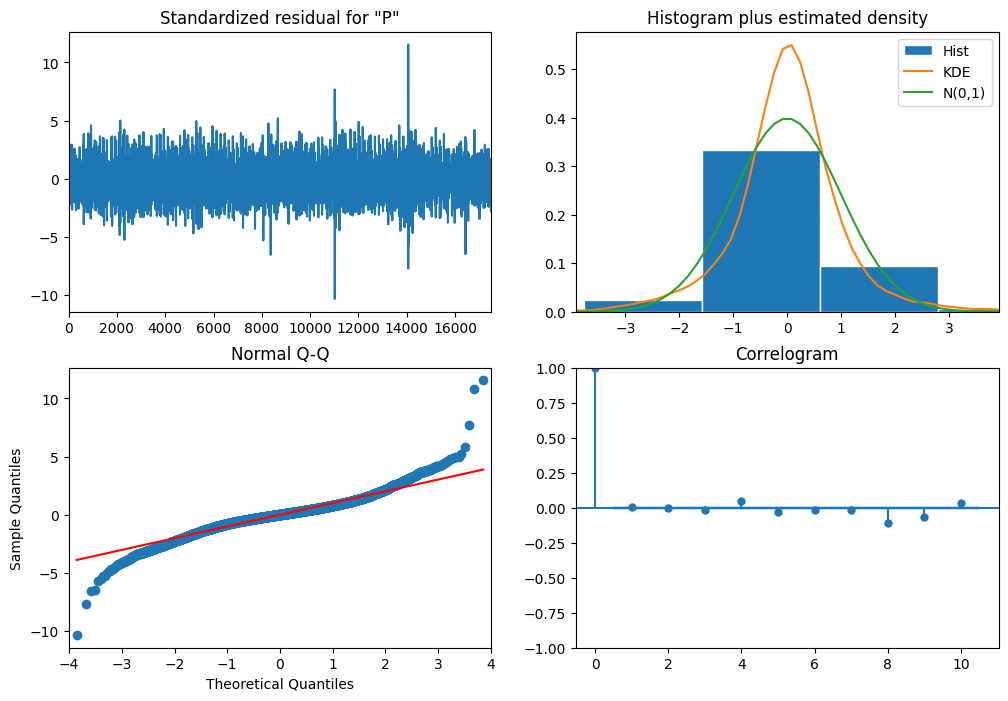

In [4]:
result.plot_diagnostics(figsize=(12, 8))
plt.show()

In [5]:
acorr_ljungbox(result.resid[50:], lags=[24], return_df=True)

,lb_stat,lb_pvalue
24,789.403039,3.575627e-151


In [6]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                            PJME_MW   No. Observations:                17520
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 24)   Log Likelihood             -123282.535
Date:                            Thu, 16 Jul 2026   AIC                         246577.070
Time:                                    16:20:29   BIC                         246623.688
Sample:                                         0   HQIC                        246592.422
                                          - 17520                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7939      0.013     59.411      0.000       0.768       0.820
ar.L2         -0.2293      0.011    -20.025      0.000      -0.252      -0.207
ma.L1          0.3073      0.013     23.064      0.000       0.281       0.333
ar.S.L24       0.3448      0.007     51.844      0.000       0.332       0.358
ma.S.L24      -0.8481      0.004   -210.108      0.000      -0.856      -0.840
sigma2      7.614e+04    456.891    166.643      0.000    7.52e+04     7.7e+04
===================================================================================
Ljung-Box (L1) (Q):                   0.62   Jarque-Bera (JB):             20539.23
Prob(Q):                              0.43   Prob(JB):                         0.00
Heteroskedasticity (H):               0.99   Skew:                             0.03
Prob(H) (two-sided):                  0.62   Kurtosis:                         8.31
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
y_pred_day = sarimax_forecast(result, test, 24)
y_pred_week = sarimax_forecast(result, test, 24*7)
y_pred_month = sarimax_forecast(result, test, 24*30)
y_pred_year = sarimax_forecast(result, test, 24*365)

In [9]:
print_metrics(test["PJME_MW"], y_pred_day, "SARIMAX Forecast (1 Day)")
print_metrics(test["PJME_MW"], y_pred_week, "SARIMAX Forecast (1 Week)")
print_metrics(test["PJME_MW"], y_pred_month, "SARIMAX Forecast (1 Month)")
print_metrics(test["PJME_MW"], y_pred_year, "SARIMAX Forecast (1 Year)")

SARIMAX Forecast (1 Day):
MAE: 1794.88
RMSE: 2606.72
MAPE: 5.58%

SARIMAX Forecast (1 Week):
MAE: 3432.75
RMSE: 4739.74
MAPE: 11.13%

SARIMAX Forecast (1 Month):
MAE: 9096.65
RMSE: 12128.76
MAPE: 29.73%

SARIMAX Forecast (1 Year):
MAE: 73781.10
RMSE: 86269.83
MAPE: 240.93%



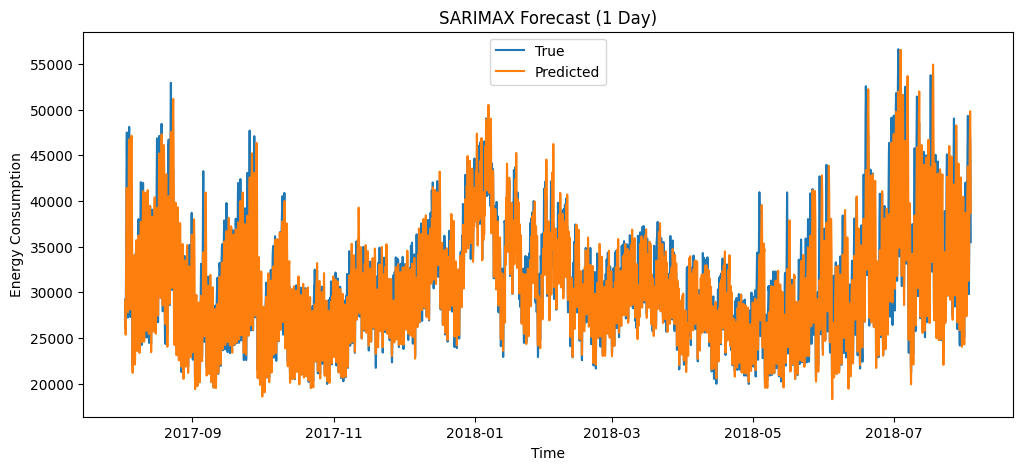

In [14]:
plot_forecast(test["PJME_MW"], y_pred_day, timesteps, "SARIMAX Forecast (1 Day)")

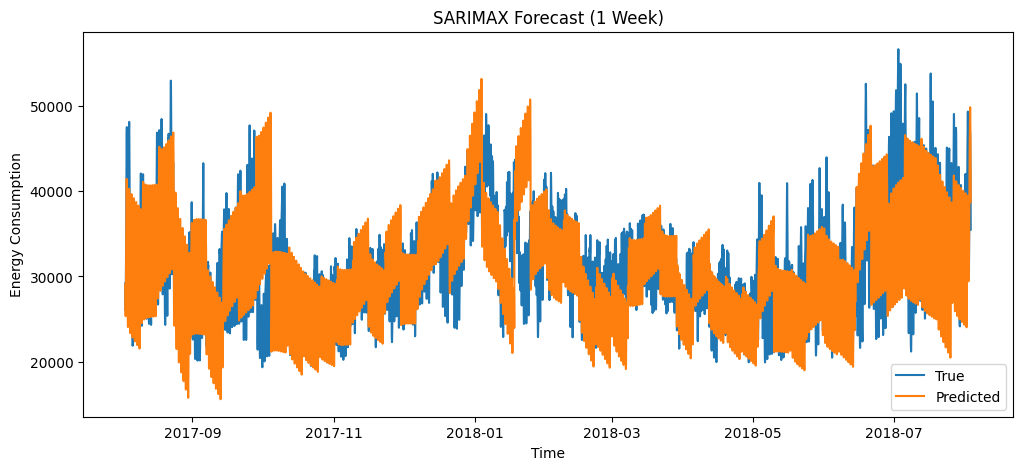

In [15]:
plot_forecast(test["PJME_MW"], y_pred_week, timesteps, "SARIMAX Forecast (1 Week)")

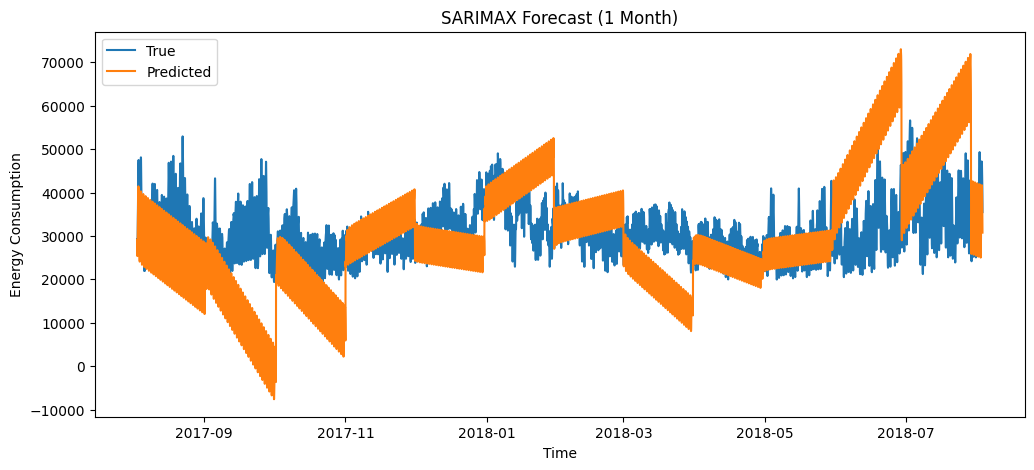

In [16]:
plot_forecast(test["PJME_MW"], y_pred_month, timesteps, "SARIMAX Forecast (1 Month)")

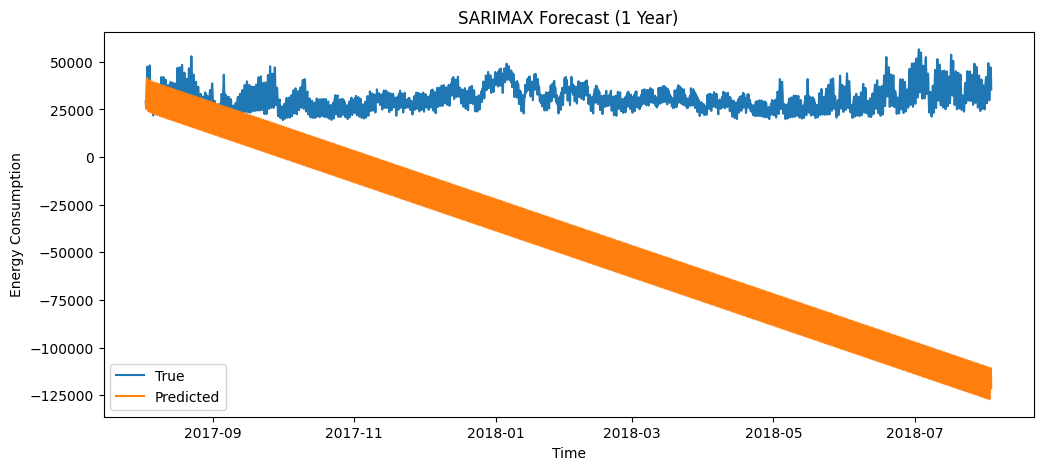

In [17]:
plot_forecast(test["PJME_MW"], y_pred_year, timesteps, "SARIMAX Forecast (1 Year)")

In [ ]:
# 1日分の予測は良い。
# 1週間分の予測は精度が落ちる。
# 1か月分の予測をさせると役に立たない。
# 1年分の予測は全く役に立たない。